In [1]:
import pandas as pd 
import numpy as nu 
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")

In [3]:
df.head()


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [5]:
df = df.drop(columns="region")

In [6]:
df

,age,sex,bmi,children,smoker,charges
0,19,female,27.900,0,yes,16884.92400
1,18,male,33.770,1,no,1725.55230
2,28,male,33.000,3,no,4449.46200
3,33,male,22.705,0,no,21984.47061
4,32,male,28.880,0,no,3866.85520
...,...,...,...,...,...,...
1333,50,male,30.970,3,no,10600.54830
1334,18,female,31.920,0,no,2205.98080
1335,18,female,36.850,0,no,1629.83350
1336,21,female,25.800,0,no,2007.94500


<Axes: xlabel='bmi', ylabel='charges'>

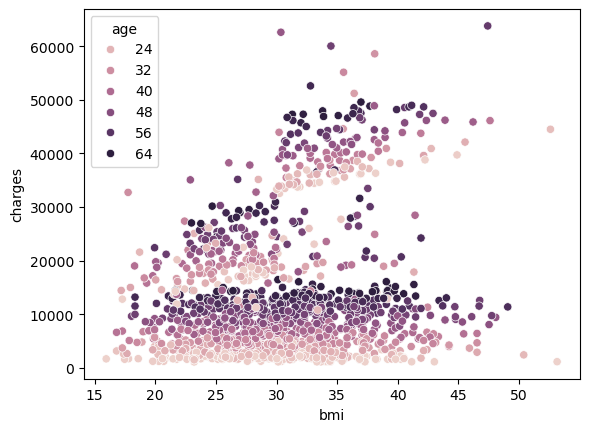

In [7]:
sns.scatterplot(x=df["bmi"],y=df["charges"],hue=df["age"])

In [8]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Encode smoker
if 'smoker' in df.columns:
    enc_smoker = OneHotEncoder(handle_unknown='ignore')
    smoker_encoded = enc_smoker.fit_transform(df[['smoker']])
    smoker_df = pd.DataFrame(smoker_encoded.toarray(),
                             columns=enc_smoker.get_feature_names_out(['smoker']))

    df.drop(columns=['smoker'], inplace=True)
    df = pd.concat([df, smoker_df], axis=1)
else:
    print("Column 'smoker' not found in the dataframe.")

# Encode sex
if 'sex' in df.columns:
    enc_sex = OneHotEncoder(handle_unknown='ignore')
    sex_encoded = enc_sex.fit_transform(df[['sex']])
    sex_df = pd.DataFrame(sex_encoded.toarray(),
                          columns=enc_sex.get_feature_names_out(['sex']))

    df.drop(columns=['sex'], inplace=True)
    df = pd.concat([df, sex_df], axis=1)
else:
    print("Column 'sex' not found in the dataframe.")


In [9]:
df[["sex_female", "sex_male"]]

,sex_female,sex_male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,0.0,1.0
...,...,...
1333,0.0,1.0
1334,1.0,0.0
1335,1.0,0.0
1336,1.0,0.0


In [10]:
from sklearn.model_selection import train_test_split
 
x_train,x_test,y_train,y_test = train_test_split(df.drop("charges",axis = 1),df["charges"],test_size=0.2,random_state=42)

In [11]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(x_train, y_train)

LinearRegression()

In [12]:
y_pred = model.predict(x_test)

In [13]:
y_pred

array([ 8554.81711589,  6973.58746745, 36798.60416104,  9417.88282303,
       26871.68031081, 11097.38383938,   145.27608963, 16746.1683771 ,
         747.53414191, 11153.67590722, 28518.15016561,  9292.18345421,
        5460.51975119, 38510.48013003, 40359.30938604, 37223.40538064,
       15316.56711945, 36047.50032223,  9326.29049907, 31400.1559532 ,
        4269.64414373, 10464.66374097,  2719.9260555 ,  6579.53742551,
       11232.00255515, 12472.06793446, 14807.11281089,  6066.19283362,
        9535.69029723,  2377.6983797 ,  9475.05690885, 12963.23366722,
        4706.09057393,  3414.674504  ,  4815.64981654, 12484.17176954,
        2359.13614479,  9161.02061228, 33238.67621442, 32743.41702445,
        4274.58967205,  4229.5442107 , 14435.36485176, 11384.66898976,
        8925.70468583, 12480.09178788,  5154.45787816,  3554.10047649,
       35649.60942684,  9276.25523701, 15971.35991397,  2552.75200479,
       12162.99980138,  1062.65132285, 13551.43771934, 12103.65505529,
      

In [17]:
from sklearn.metrics import r2_score

print("accuracy:", r2_score(y_test, y_pred))
r2=r2_score(y_test, y_pred)

accuracy: 0.7811302113434095


In [16]:
x_test.shape
n = x_test.shape[0]
p = x_test.shape[1]

In [18]:
#adjusted r-squared

a_rSquared = (1-((1-r2)*(n-1)/(n-p-1)))

In [19]:
print("adjusted r-squared",a_rSquared)

adjusted r-squared 0.7752375631872706
